<a href="https://colab.research.google.com/github/minji25-hue/C-programming/blob/20250526/yolov8_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 초기 환경 설정

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
import os
from ultralytics import YOLO
import shutil
from google.colab import drive
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
uploaded = files.upload()

Saving Test.v1i.yolov8.zip to Test.v1i.yolov8.zip


In [ ]:
!unzip /content/Test.v1i.yolov8.zip -d /content/dataset

Archive:  /content/Test.v1i.yolov8.zip
  inflating: /content/dataset/README.dataset.txt  
  inflating: /content/dataset/README.roboflow.txt  
  inflating: /content/dataset/data.yaml  
   creating: /content/dataset/train/
   creating: /content/dataset/train/images/
 extracting: /content/dataset/train/images/106-_jpg.rf.80151e9f3b1f297569b25312da0986fd.jpg  
 extracting: /content/dataset/train/images/107-_jpg.rf.38963afb86984aafeb1a9f73931e5fc7.jpg  
 extracting: /content/dataset/train/images/108-_jpg.rf.171a1b76c65822e717e7abd133883bd8.jpg  
 extracting: /content/dataset/train/images/109-_jpg.rf.c72cd02cacbdbebd90b7c7c29cbaee92.jpg  
 extracting: /content/dataset/train/images/110-_jpg.rf.39efa3475209bbce713a481155f8e5bf.jpg  
 extracting: /content/dataset/train/images/111-_jpg.rf.2881fe4a1373a4c0e5adf11a23255a70.jpg  
 extracting: /content/dataset/train/images/112-_jpg.rf.16c052f6b8ac237d4552eff9d67e5fc9.jpg  
 extracting: /content/dataset/train/images/113-_jpg.rf.c839977e1ce60333458b65

다음 폴더 구조를 수정합니다.

/content/
|----data
|   |----train
|

In [27]:
# test 폴더가 없으면 먼저 생성
!mkdir -p /content/dataset/test/images

# 모든 이미지 파일 복사
!cp /content/dataset/train/images/* /content/dataset/test/images/

In [28]:
# valid 폴더가 없으면 먼저 생성
!mkdir -p /content/dataset/valid/images

# 모든 이미지 파일 복사
!cp /content/dataset/train/images/* /content/dataset/valid/images/

In [ ]:
# lables 폴더가 없으면 먼저 생성
!mkdir -p /content/dataset/valid/labels

# 모든 이미지 파일 복사
!cp /content/dataset/train/labels * /content/dataset/valid/labels

cp: -r not specified; omitting directory '/content/dataset/train/labels'
cp: -r not specified; omitting directory 'dataset'
cp: -r not specified; omitting directory 'sample_data'


In [ ]:
model = YOLO('yolov8x-seg.pt')  # nano 모델 사용 (n, s, m, l, x 중 선택)

100%|██████████| 137M/137M [00:00<00:00, 290MB/s]


In [49]:
results = model.train(
    data='/content/dataset/data.yaml',  # 데이터셋 설정 파일
    epochs=50,                         # 학습 에폭 수
    imgsz=640,                         # 이미지 크기
    batch=16,                          # 배치 크기
    name='yolov8-seg_custom',              # 프로젝트 이름
    project='/content/runs/train',     # 저장 경로
    patience=10,                       # Early stopping patience
    save=True,                         # 체크포인트 저장
    device=0                           # GPU 사용
)

Ultralytics 8.3.145 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/train/yolov8-seg_custom9/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8-seg_custom10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

train: Scanning /content/dataset/train/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100%|██████████| 15/15 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 414.1±218.7 MB/s, size: 21.4 KB)


val: Scanning /content/dataset/valid/labels.cache... 0 images, 15 backgrounds, 0 corrupt: 100%|██████████| 15/15 [00:00<?, ?it/s]

...

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.55it/s]
/usr/local/lib/python3.11/dist-packages/ultralytics/utils/metrics.py:548: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.11/dist-packages/ultralytics/utils/metrics.py:593: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.11/dist-packages/ultralytics/utils/metrics.py:593: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/l

                   all         15          0          0          0          0          0          0          0          0          0
WARNING ⚠️ no labels found in segment set, can not compute metrics without labels


/usr/local/lib/python3.11/dist-packages/ultralytics/utils/metrics.py:731: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index


Speed: 0.2ms preprocess, 34.5ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/train/yolov8-seg_custom10


In [50]:
# 학습된 모델 로드
model = YOLO('/content/runs/train/yolov8-seg_custom9/weights/best.pt')

# 테스트 실행
results = model.predict(
    source='/content/dataset/test/images',  # 테스트 이미지 경로
    save=True,                              # 결과 저장
    save_txt=True,                          # 텍스트 결과도 저장
    conf=0.5,                               # 신뢰도 임계값
    project='/content/runs/detect',         # 저장 프로젝트 경로
    name='test_results'                     # 폴더 이름 지정
)


image 1/15 /content/dataset/test/images/106-_jpg.rf.80151e9f3b1f297569b25312da0986fd.jpg: 640x640 4 dotted-lines, 1 left-lane, 2 left_lines, 2 right-lanes, 1 right_line, 88.3ms
image 2/15 /content/dataset/test/images/107-_jpg.rf.38963afb86984aafeb1a9f73931e5fc7.jpg: 640x640 4 dotted-lines, 1 left-lane, 1 left_line, 1 right-lane, 1 right_line, 68.2ms
image 3/15 /content/dataset/test/images/108-_jpg.rf.171a1b76c65822e717e7abd133883bd8.jpg: 640x640 6 dotted-lines, 1 left-lane, 2 left_lines, 1 right-lane, 1 right_line, 65.0ms
image 4/15 /content/dataset/test/images/109-_jpg.rf.c72cd02cacbdbebd90b7c7c29cbaee92.jpg: 640x640 4 dotted-lines, 1 left-lane, 1 left_line, 1 right-lane, 1 right_line, 64.8ms
image 5/15 /content/dataset/test/images/110-_jpg.rf.39efa3475209bbce713a481155f8e5bf.jpg: 640x640 4 dotted-lines, 1 left-lane, 2 left_lines, 1 right-lane, 1 right_line, 65.4ms
image 6/15 /content/dataset/test/images/111-_jpg.rf.2881fe4a1373a4c0e5adf11a23255a70.jpg: 640x640 5 dotted-lines, 1 left

In [42]:
!find /content/runs/train -name best.pt

/content/runs/train/yolov8-seg_custom9/weights/best.pt


In [45]:
import cv2

def draw_enhanced_results(image_path, results):
    """세그멘테이션 마스크를 이미지 위에 시각화"""
    # 이미지 로드
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 클래스 색상 정의
    class_names = ['dotted-line', 'left_lane', 'left_line', 'right_lane', 'right_line']
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]

    for result in results:
        masks = result.masks  # 마스크 객체

        if masks is not None and masks.data is not None:
            mask_data = masks.data.cpu().numpy()  # (N, H, W)
            cls_list = result.boxes.cls.cpu().numpy().astype(int)  # 클래스 인덱스 리스트
            conf_list = result.boxes.conf.cpu().numpy()  # 신뢰도

            for i in range(len(mask_data)):
                mask = mask_data[i]
                cls_id = cls_list[i]
                conf = conf_list[i]

                # 마스크 색상 및 클래스 이름
                color = colors[cls_id % len(colors)]
                class_name = class_names[cls_id] if cls_id < len(class_names) else f'class_{cls_id}'
                label = f'{class_name}: {conf:.2f}'

                # 마스크를 컬러로 적용
                colored_mask = np.zeros_like(img_rgb, dtype=np.uint8)
                for c in range(3):
                    colored_mask[:, :, c] = mask * color[c]

                # 반투명하게 overlay
                img_rgb = cv2.addWeighted(img_rgb, 1.0, colored_mask, 0.4, 0)

                # 마스크 경계 추출하여 텍스트 위치 추정
                contours, _ = cv2.findContours((mask * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if contours:
                    x, y, w, h = cv2.boundingRect(contours[0])
                    # 라벨 텍스트
                    (text_width, text_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
                    cv2.rectangle(img_rgb, (x, y - text_height - 10), (x + text_width, y), color, -1)
                    cv2.putText(img_rgb, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return img_rgb

Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


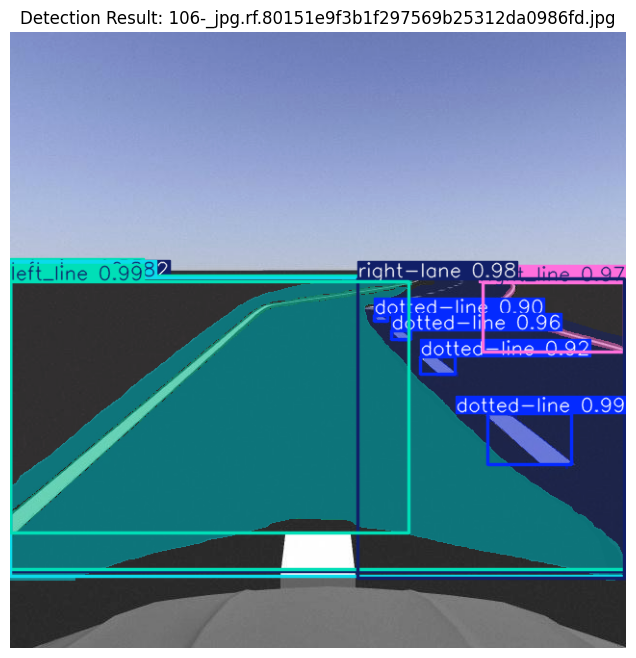

Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


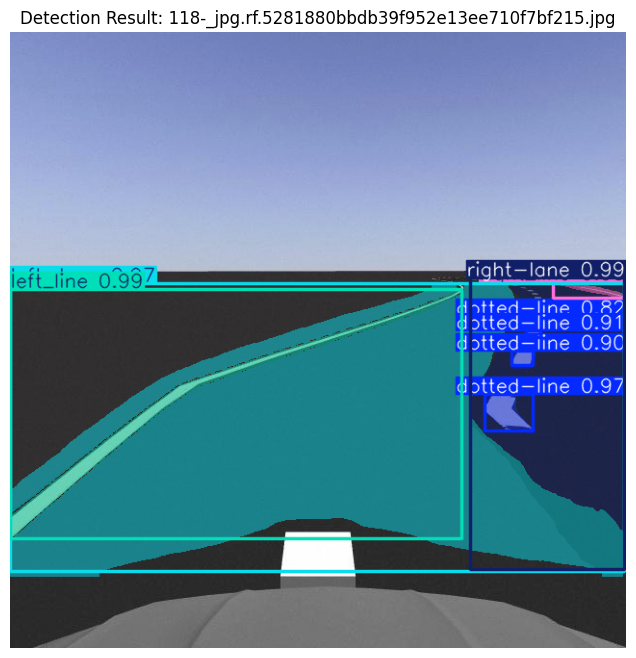

Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


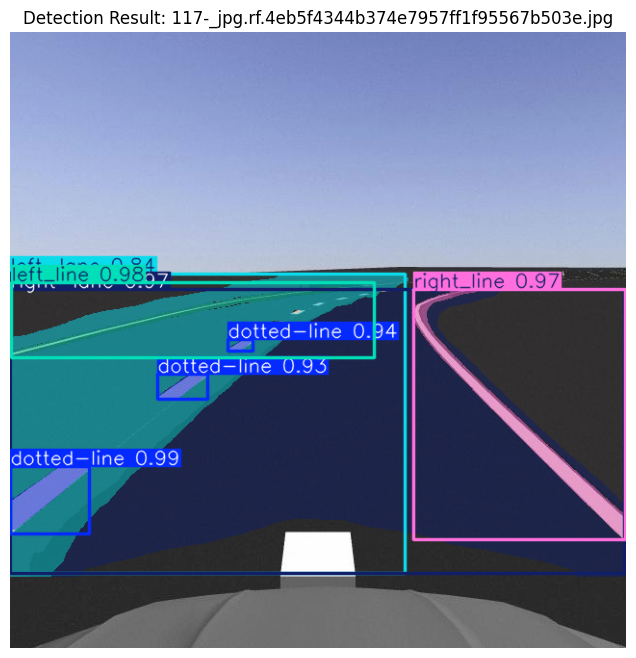

Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


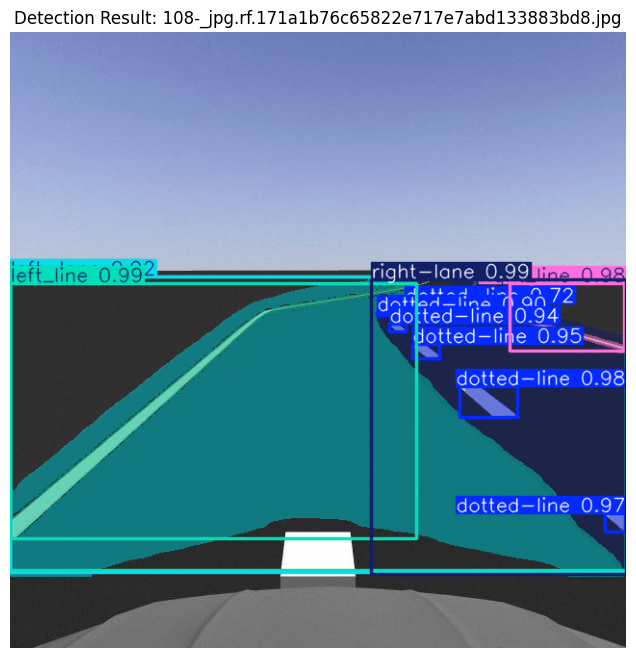

Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


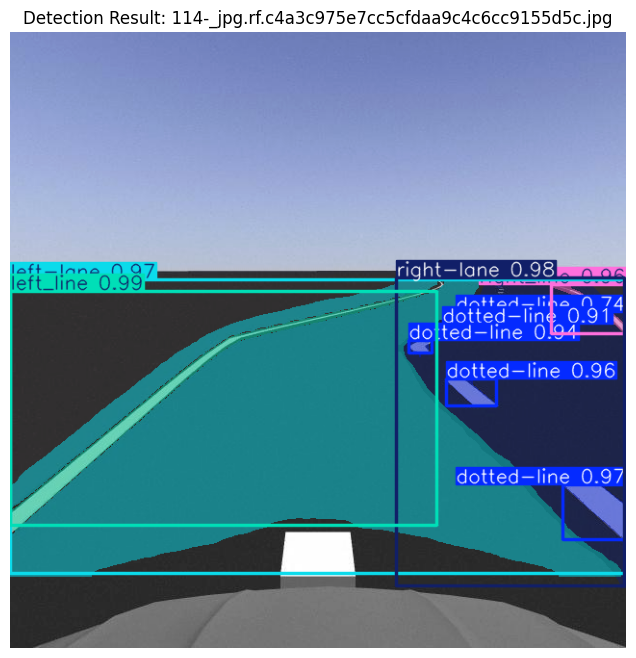

In [48]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 테스트 이미지 목록 가져오기
import os
test_images = os.listdir('/content/dataset/test/images')

# 처음 5개 이미지 예측 및 시각화
for i, img_name in enumerate(test_images[:5]):
    img_path = f'/content/dataset/test/images/{img_name}'

    # 예측 실행
    results = model.predict(img_path, conf=0.5, verbose=False)

    # 결과 시각화 (첫 결과 기준)
    plotted_img = results[0].plot()  # numpy array (BGR)

    # BGR → RGB 변환 후 표시
    plt.figure(figsize=(12, 8))
    plt.imshow(plotted_img[..., ::-1])  # RGB로 변환
    plt.title(f'Detection Result: {img_name}')
    plt.axis('off')
    plt.show()

In [51]:
import shutil
from google.colab import files

# 1. zip 파일로 압축 (기존 zip 파일이 있다면 덮어씌움)
shutil.make_archive('/content/runs_backup', 'zip', '/content/runs')

# 2. 다운로드 링크 제공
files.download('/content/runs_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
#동영상으로 만들기

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# YOLO 예측 + 시각화 함수 (콜라보용)
image_dir = '/content/dataset/test/images/'
test_images = sorted([img for img in os.listdir(image_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))])

frames = []

for i, img_name in enumerate(test_images[:5]):  # 처음 5개만
    img_path = os.path.join(image_dir, img_name)

    # 예측 실행
    result = model.predict(img_path, conf=0.5, verbose=False)

    # 향상된 시각화
    enhanced_img = draw_enhanced_results(img_path, result)

    # RGB -> BGR (OpenCV용)
    bgr_img = cv2.cvtColor(np.array(enhanced_img), cv2.COLOR_RGB2BGR)

    # 모든 프레임 사이즈를 동일하게 유지
    bgr_img = cv2.resize(bgr_img, (1280, 720))

    frames.append(bgr_img)

# 🔄 동영상 생성
video_path = "/content/detection_results.mp4"
fps = 2  # 0.5초 간격 = 2프레임/초
height, width, _ = frames[0].shape
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # 코덱 설정

out = cv2.VideoWriter(video_path, fourcc, fps, (width, height))

for frame in frames:
    out.write(frame)

out.release()
print(f"✅ 영상 저장 완료: {video_path}")

# Colab에서 다운로드 링크 제공
from google.colab import files
files.download(video_path)

Results saved to /content/runs/detect/test_results2
15 labels saved to /content/runs/detect/test_results2/labels
Results saved to /content/runs/detect/test_results2
15 labels saved to /content/runs/detect/test_results2/labels
Results saved to /content/runs/detect/test_results2
15 labels saved to /content/runs/detect/test_results2/labels
Results saved to /content/runs/detect/test_results2
15 labels saved to /content/runs/detect/test_results2/labels
Results saved to /content/runs/detect/test_results2
15 labels saved to /content/runs/detect/test_results2/labels
✅ 영상 저장 완료: /content/detection_results.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>